# Adversarial Perturbation vs. Lipschitz Bound (CNN)

## Motivation

`layer_decomposition.py` (sibling module, one level up) computes two theoretical upper bounds
on how much a trained CNN's full 10-d logit vector can move per unit of input change:

- **`L_full_estimated`** -- the TIGHT bound: the network's own empirical Lipschitz constant,
  measured directly on `f = head o extractor`.
- **`product_bound`** (`L_extractor_estimated * L_head_exact`) -- the LOOSE bound: the classic
  submultiplicative per-layer bound (Szegedy et al., 2014, *"Intriguing Properties of Neural
  Networks"*), which `layer_decomposition_experiment` already finds to be loose by roughly
  2.4x-155x depending on estimator/width.

Looseness by itself doesn't say whether it *matters in practice* -- a 16x-loose bound is still a
valid certificate, just not a tight one. This notebook asks the practical question directly:
generate real FGSM/PGD adversarial examples against the same trained checkpoint, and check
whether their achieved sensitivity ratio lands close to the tight bound, close to the loose
bound, or well below both.

**Two caveats worth keeping in view throughout:**

1. **This project has two different "L_full"-like quantities.** The main
   `notebook_mnist_lipschitz.ipynb` measures Lipschitz estimates on the scalar **margin**
   function (`models.margin_fn`) -- that's the project's usual robustness measure.
   `layer_decomposition.py`, and this notebook, instead measure on the **full 10-d logit
   vector** -- the function the submultiplicative bound actually bounds. `achieved_ratio`
   below is deliberately computed on the full logit vector to match, not the margin.
2. **The achieved ratio is a LOWER BOUND on the network's true worst-case sensitivity, not the
   worst case itself.** FGSM/PGD maximize cross-entropy loss, not the ratio directly -- a
   ratio-maximizing search could in principle find something larger. Results below should be
   read as "achieved under this attack," never as "the" worst case.

## What this notebook does

Thin driver notebook -- all reusable logic lives in `attacks.py` (FGSM/PGD), `run_experiment.py`
(filtering, the achieved-ratio metric, the epsilon sweep, and reuse of
`layer_decomposition_experiment` for the two bounds), and `plots.py`. This notebook only calls
into them and displays results. See `mnist_lipschitz/adversarial/run_experiment.py`'s module
docstring for the full design rationale.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline

from mnist_lipschitz.adversarial import run_experiment
from mnist_lipschitz.adversarial import plots as adv_plots


## Baseline checkpoint: train, then compare against both bounds

`run_experiment.main()` encapsulates the single-checkpoint pipeline: trains the project's
default `SmallCNN` (`conv_channels=(16, 32)`, matching every other CNN trained elsewhere in this
project) on full MNIST, computes `L_full_estimated`/`product_bound` via
`layer_decomposition.layer_decomposition_experiment` (reused directly, not recomputed
independently -- see `run_experiment.py`'s top docstring for why that matters), then runs FGSM
and PGD across `epsilon in {0.05, 0.1, 0.15, 0.2, 0.25}` (Goodfellow et al. 2015's MNIST range)
against 500 correctly-classified held-out points, with PGD using 20 steps, 5 random restarts,
and step size `epsilon / 4`.


In [2]:
summary_df, sweep_results = run_experiment.main(seed=0, verbose=True)


  epoch  1/8  train loss 0.5189


  epoch  2/8  train loss 0.1305


  epoch  3/8  train loss 0.0859


  epoch  4/8  train loss 0.0680


  epoch  5/8  train loss 0.0593


...

  epsilon=0.05  FGSM  mean_R_adv=3.0648  max_R_adv=4.6319  pct_misclassified=0.0460
  epsilon=0.05  PGD   mean_R_adv=3.7556  max_R_adv=5.4345  pct_misclassified=0.0680


  epsilon=0.1  FGSM  mean_R_adv=3.0198  max_R_adv=4.3657  pct_misclassified=0.2160
  epsilon=0.1  PGD   mean_R_adv=3.9208  max_R_adv=5.3710  pct_misclassified=0.4680


  epsilon=0.15  FGSM  mean_R_adv=2.9935  max_R_adv=4.1765  pct_misclassified=0.5380
  epsilon=0.15  PGD   mean_R_adv=4.0867  max_R_adv=5.5157  pct_misclassified=0.9320


  epsilon=0.2  FGSM  mean_R_adv=2.9625  max_R_adv=4.0683  pct_misclassified=0.8100
  epsilon=0.2  PGD   mean_R_adv=4.2954  max_R_adv=5.5873  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=2.9072  max_R_adv=4.0098  pct_misclassified=0.9620
  epsilon=0.25  PGD   mean_R_adv=4.4493  max_R_adv=5.6603  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    3.064751      3.098721   4.631892              0.046          5.564095       91.15376         0.832461                0.050814
    0.10   FGSM    3.019823      3.059410   4.365731              0.216          5.564095       91.15376         0.784626                0.047894
    0.15   FGSM    2.993540      3.039454   4.176502              0.538          5.564095       91.15376         0.750617                0.045818
    0.20   FGSM    2.962480      3.020506   4.068300              0.810          5.564095       91.15376         0.731170                0.044631
    0.25   FGSM    2.907182      2.957798   4.009825              0.962          5.564095       91.153

**What to look for**: `mean_R_adv`/`median_R_adv`/`max_R_adv` are the achieved sensitivity
ratio's summary statistics (Euclidean, full logit vector -- see the caveats above);
`pct_misclassified` is the attack's success rate at that epsilon. `ratio_to_L_full` and
`ratio_to_product_bound` are `max_R_adv` divided by each bound -- `ratio_to_L_full` should stay
at or below 1 (the tight bound is a valid upper bound on any achieved ratio by construction), and
a value slightly over 1 triggers a printed warning above rather than failing silently: it almost
always means `L_full_estimated` itself under-sampled (a `pairwise` estimate over a few hundred
query points), not a genuine violation of the bound -- see `summarize_epsilon_sweep`'s
docstring. `ratio_to_product_bound` is expected to stay far below 1, since `product_bound` is the
loose bound.


In [3]:
summary_df


,epsilon,method,mean_R_adv,median_R_adv,max_R_adv,pct_misclassified,L_full_estimated,product_bound,ratio_to_L_full,ratio_to_product_bound
0,0.05,FGSM,3.064751,3.098721,4.631892,0.046,5.564095,91.15376,0.832461,0.050814
1,0.10,FGSM,3.019823,3.059410,4.365731,0.216,5.564095,91.15376,0.784626,0.047894
2,0.15,FGSM,2.993540,3.039454,4.176502,0.538,5.564095,91.15376,0.750617,0.045818
3,0.20,FGSM,2.962480,3.020506,4.068300,0.810,5.564095,91.15376,0.731170,0.044631
4,0.25,FGSM,2.907182,2.957798,4.009825,0.962,5.564095,91.15376,0.720661,0.043990
5,0.05,PGD,3.755569,3.750254,5.434491,0.068,5.564095,91.15376,0.976707,0.059619
6,0.10,PGD,3.920766,3.906701,5.371040,0.468,5.564095,91.15376,0.965303,0.058923
7,0.15,PGD,4.086692,4.069917,5.515675,0.932,5.564095,91.15376,0.991298,0.060510
8,0.20,PGD,4.295442,4.291698,5.587313,1.000,5.564095,91.15376,1.004173,0.061295
9,0.25,PGD,4.449301,4.447917,5.660318,1.000,5.564095,91.15376,1.017294,0.062096


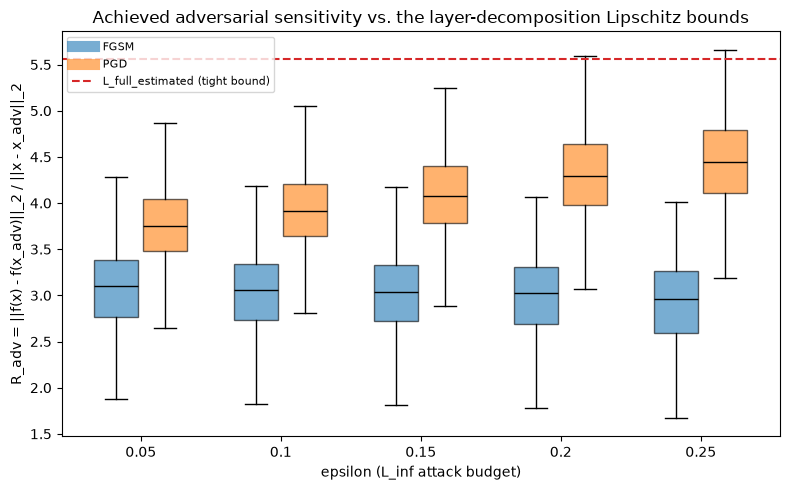

In [4]:
L_full_estimated = summary_df["L_full_estimated"].iloc[0]
product_bound = summary_df["product_bound"].iloc[0]

fig_dist = adv_plots.plot_R_adv_distribution(
    sweep_results, L_full_estimated, product_bound,
    save_path=run_experiment.RESULTS_DIR / "adversarial_R_adv_distribution_baseline.png")


## CNN-width sweep

Does achieved sensitivity track the tight bound or the loose bound more closely as the network
gets wider -- i.e. does the practical gap this notebook measures narrow or widen with capacity,
the same way `layer_decomposition.py`'s own looseness-ratio-vs-width sweep does for the
*theoretical* gap?

`run_cnn_adversarial_width_sweep` repeats the baseline pipeline across the same widths as
`layer_decomposition.run_cnn_width_sweep` (`(4, 8, 16, 32, 64)`, same `conv_channels=(width,
2*width)` convention). No checkpoints from that sweep are saved to disk, so this trains fresh
`SmallCNN`s at each width using the identical training configuration, rather than reusing weights
that don't exist on disk -- see `run_cnn_adversarial_width_sweep`'s docstring.


In [5]:
combined_df, per_width_summary_dfs, per_width_extremes = run_experiment.run_cnn_adversarial_width_sweep(seed=0, verbose=True)


=== width=4 (conv_channels=(4, 8)) ===


  train_acc=0.8960  test_acc=0.8973
  [pairwise] L_head_exact=1.5897  L_head_est=1.0607  L_extractor_est=4.4783  L_full_est=3.0515  looseness_ratio=2.3329  looseness_ratio_estimated=1.5566
filter_correctly_classified: kept 0.8915 of the pool (1783/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=2.1634  max_R_adv=3.2454  pct_misclassified=0.2440
  epsilon=0.05  PGD   mean_R_adv=2.3836  max_R_adv=3.3630  pct_misclassified=0.2820


  epsilon=0.1  FGSM  mean_R_adv=2.1732  max_R_adv=3.2767  pct_misclassified=0.6060
  epsilon=0.1  PGD   mean_R_adv=2.4844  max_R_adv=3.5075  pct_misclassified=0.7320


  epsilon=0.15  FGSM  mean_R_adv=2.1564  max_R_adv=3.2791  pct_misclassified=0.8660
  epsilon=0.15  PGD   mean_R_adv=2.5280  max_R_adv=3.6327  pct_misclassified=0.9520


...

  epsilon=0.15  PGD   mean_R_adv=2.5965  max_R_adv=3.7934  pct_misclassified=0.5320


  epsilon=0.2  FGSM  mean_R_adv=2.1734  max_R_adv=3.3023  pct_misclassified=0.5920


  epsilon=0.2  PGD   mean_R_adv=2.7459  max_R_adv=3.8323  pct_misclassified=0.8840


  epsilon=0.25  FGSM  mean_R_adv=2.1913  max_R_adv=3.3793  pct_misclassified=0.8120


  epsilon=0.25  PGD   mean_R_adv=2.9205  max_R_adv=4.0268  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    2.138283      2.152349   3.428058              0.054          4.375882      26.812752         0.783398                0.127852
    0.10   FGSM    2.134259      2.149210   3.397999              0.138          4.375882      26.812752         0.776529                0.126731
    0.15   FGSM    2.152991      2.176349   3.373949              0.336          4.375882      26.812752         0.771033                0.125834
    0.20   FGSM    2.173365      2.202104   3.302324              0.592          4.375882      26.812752         0.754665                0.123162
    0.25   FGSM    2.191272      2.216887   3.379328              0.812          4.375882      26.812752         0.772262                0.126034
    0.05    PGD    2.409423      2.40597

In [6]:
combined_df


,width,train_acc,test_acc,L_full_estimated,product_bound,max_R_adv_fgsm,ratio_to_L_full_fgsm,ratio_to_product_bound_fgsm,max_R_adv_pgd,ratio_to_L_full_pgd,ratio_to_product_bound_pgd
0,4,0.8960,0.8973,3.051536,7.118990,3.241846,1.062365,0.455380,3.732785,1.223248,0.524342
1,8,0.9228,0.9228,3.261557,8.814581,3.160682,0.969072,0.358574,3.920044,1.201894,0.444723
2,16,0.9462,0.9393,3.197397,9.922486,3.082276,0.963995,0.310635,3.864386,1.208604,0.389457
3,32,0.9756,0.9646,3.767004,12.908549,3.026486,0.803420,0.234456,3.834688,1.017967,0.297066
4,64,0.9916,0.9706,4.375882,26.812752,3.379328,0.772262,0.126034,4.026835,0.920234,0.150184


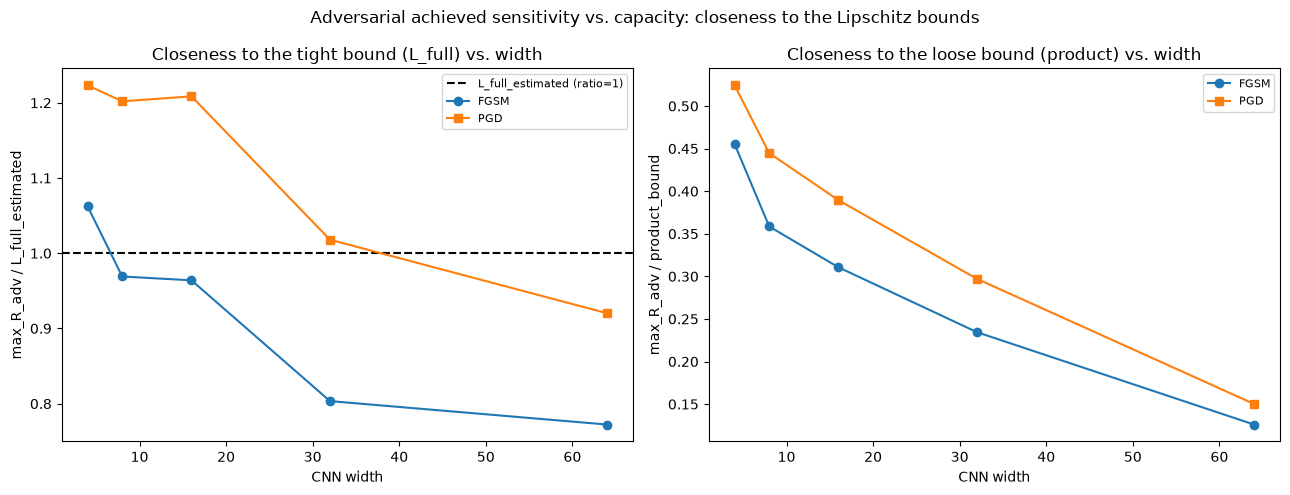

In [7]:
fig_width = adv_plots.plot_bound_closeness_vs_width(
    combined_df, save_path=run_experiment.RESULTS_DIR / "adversarial_bound_closeness_vs_width.png")


## Most and least sensitive attacked example, per width

For each width, across every `(epsilon, method)` case in that checkpoint's sweep: the single
attacked point whose achieved ratio `R_adv` was the LARGEST (the sharpest sensitivity this
attack found), and the single one whose `R_adv` was the SMALLEST (still an attacked,
correctly-classified point -- just the one this attack moved the least in logit space per unit
of pixel change, not an unperturbed point). Each row below is clean image / adversarial image /
their pixel-space difference, with the true class, the model's prediction on each, and the
epsilon/method/R_adv that produced it.

**Also shown, per example, tracing the pixel -> feature -> logit distance chain**:

1. `pixel_distance` (under the clean image): the INITIAL Euclidean distance in raw pixel space,
   `||x - x_adv||_2`, before either image reaches the extractor -- exactly `R_adv`'s denominator.
2. `feature_distance` (under the adversarial image): the Euclidean distance between the CNN's
   extracted features -- `model.extractor`'s output, right before the final linear `head` --
   compared against that specific head layer's own EXACT Lipschitz bound
   (`layer_decomposition.py`'s `L_head_exact`, the head weight matrix's spectral norm). For a
   linear layer, `||head(a) - head(b)||_2 <= L_head_exact * ||a - b||_2` always holds -- not an
   estimate, Cauchy-Schwarz applied to the weight matrix -- so `actual` should never exceed
   `head_bound`. How close `actual` gets to `head_bound` (the reported percentage) shows whether
   this specific pair of extracted features happened to differ mostly along the head's single
   most logit-sensitive direction (its top singular vector, close to 100%) or a much less
   sensitive one (well under 100%) -- this is the SAME per-layer bound `layer_decomposition.py`'s
   `looseness_ratio` checks in aggregate over many pairs, here inspected for these two specific,
   extreme examples.

See `run_experiment.most_and_least_sensitive_examples`'s and `head_layer_bound_check`'s
docstrings for the exact computations.


width=4:
  most sensitive : R_adv=3.7328  eps=0.25 PGD  true=7  pred_clean=7  pred_adv=2
    pixel_distance=4.8879  feature_distance=13.3462  L_head_exact=1.9361  head_bound=25.8395  actual_logit_distance=18.2454  (70.6% of bound)
  least sensitive: R_adv=1.0305  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=0.9682  feature_distance=2.0763  L_head_exact=1.9361  head_bound=4.0199  actual_logit_distance=0.9978  (24.8% of bound)
width=8:
  most sensitive : R_adv=3.9200  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixel_distance=5.0181  feature_distance=14.6411  L_head_exact=1.8972  head_bound=27.7772  actual_logit_distance=19.6711  (70.8% of bound)
  least sensitive: R_adv=0.9166  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=0.9766  feature_distance=1.8443  L_head_exact=1.8972  head_bound=3.4991  actual_logit_distance=0.8952  (25.6% of bound)
width=16:
  most sensitive : R_adv=3.8644  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixe

width=32:
  most sensitive : R_adv=3.8347  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixel_distance=4.8673  feature_distance=19.8110  L_head_exact=1.7633  head_bound=34.9335  actual_logit_distance=18.6644  (53.4% of bound)
  least sensitive: R_adv=1.0526  eps=0.1 FGSM  true=2  pred_clean=2  pred_adv=8
    pixel_distance=2.1516  feature_distance=6.3562  L_head_exact=1.7633  head_bound=11.2081  actual_logit_distance=2.2649  (20.2% of bound)
width=64:
  most sensitive : R_adv=4.0268  eps=0.25 PGD  true=5  pred_clean=5  pred_adv=8
    pixel_distance=4.7255  feature_distance=24.7770  L_head_exact=1.6595  head_bound=41.1178  actual_logit_distance=19.0290  (46.3% of bound)
  least sensitive: R_adv=1.0287  eps=0.25 FGSM  true=1  pred_clean=1  pred_adv=4
    pixel_distance=5.1163  feature_distance=17.7253  L_head_exact=1.6595  head_bound=29.4154  actual_logit_distance=5.2629  (17.9% of bound)


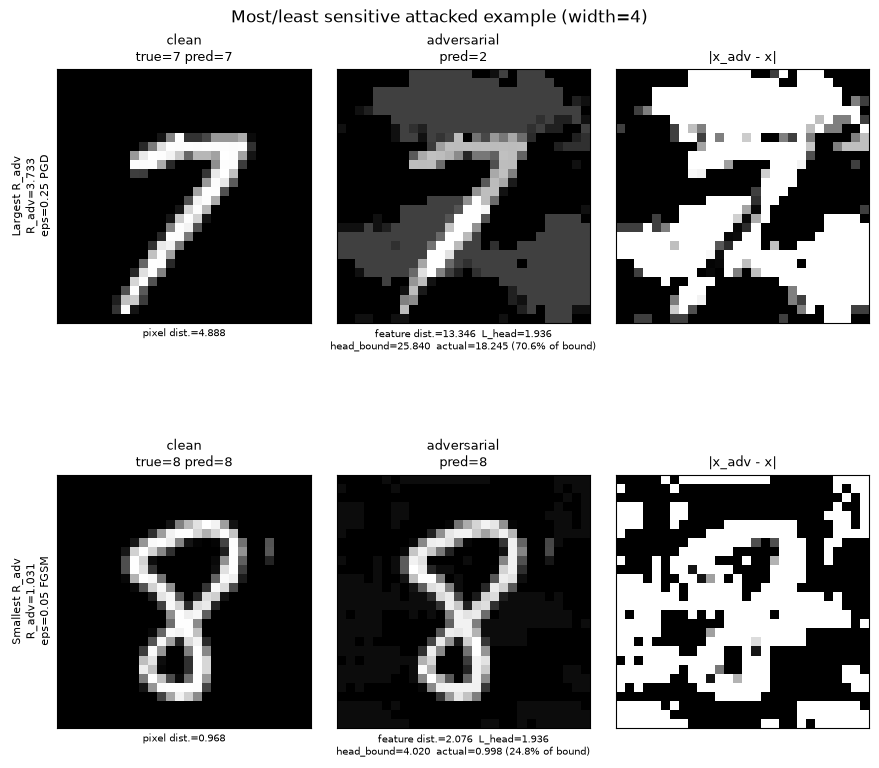

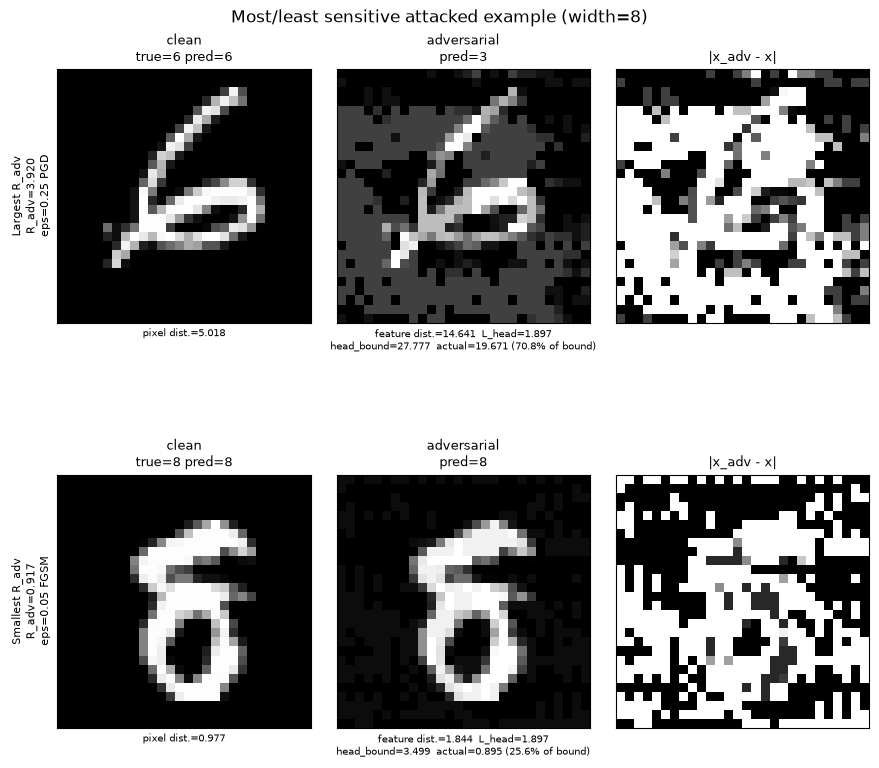

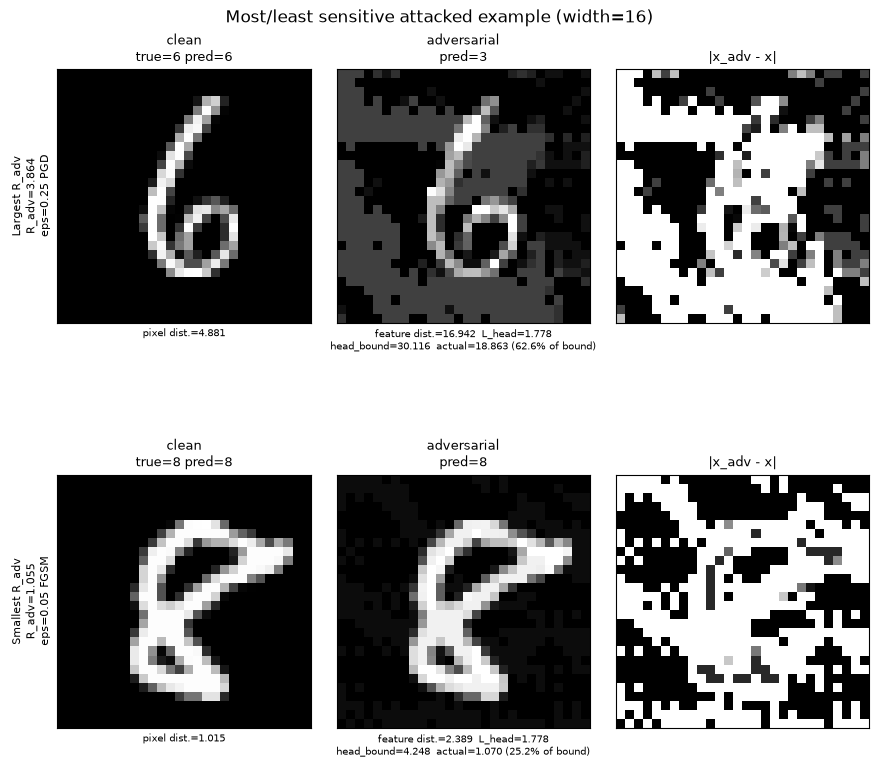

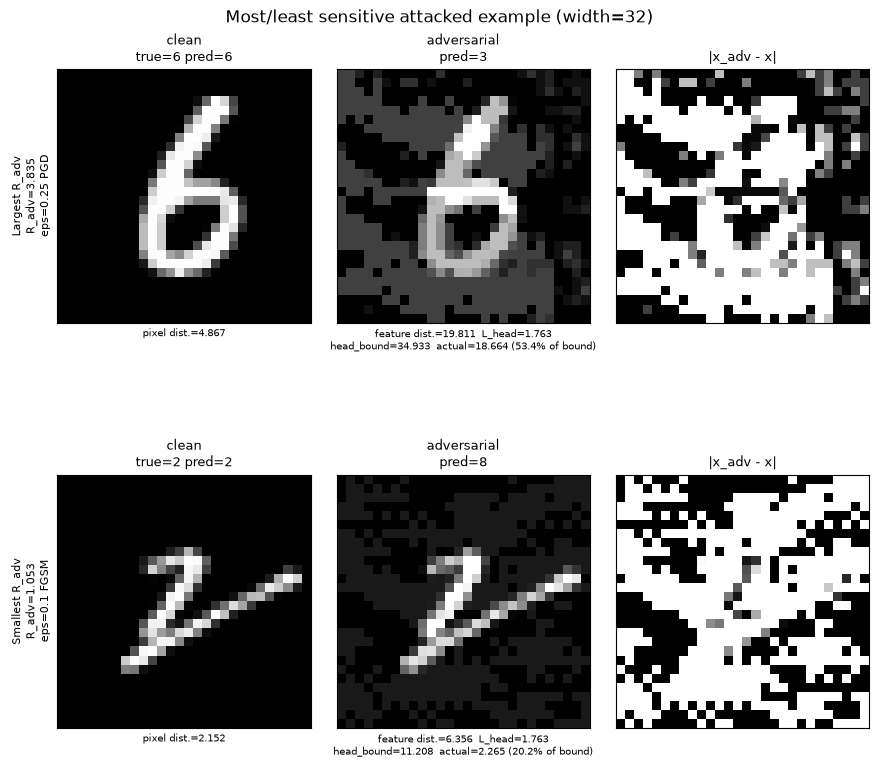

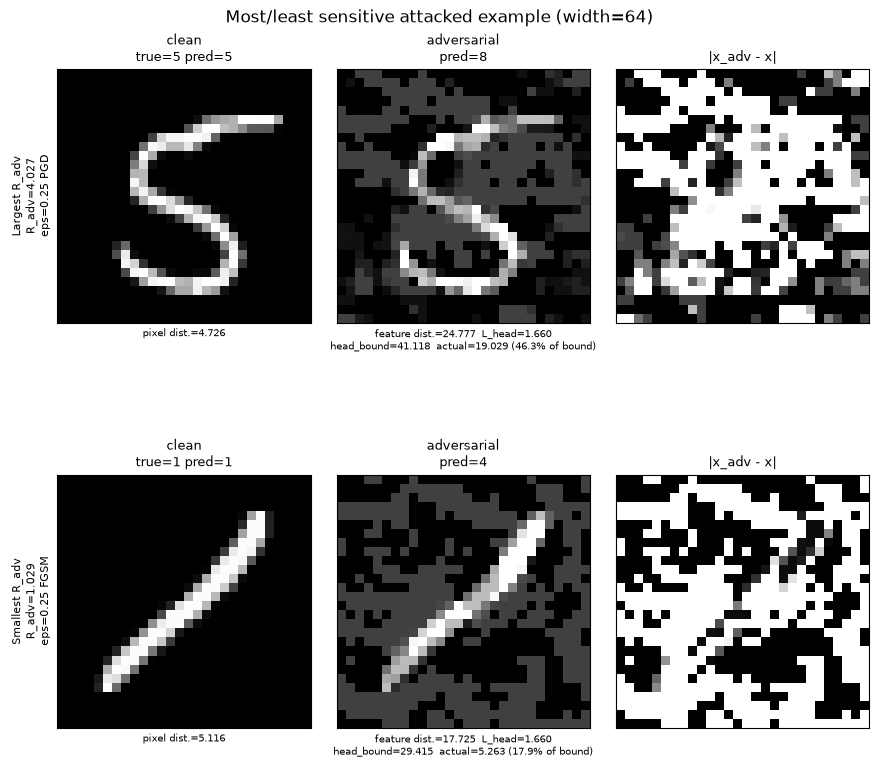

In [8]:
for width in combined_df["width"]:
    most_sensitive, least_sensitive = per_width_extremes[width]
    print(f"width={width}:")
    for label, example in (("most sensitive ", most_sensitive), ("least sensitive", least_sensitive)):
        print(f"  {label}: R_adv={example['R_adv']:.4f}  "
              f"eps={example['epsilon']:g} {example['method']}  "
              f"true={example['y_true']}  pred_clean={example['pred_clean']}  "
              f"pred_adv={example['pred_adv']}")
        print(f"    pixel_distance={example['pixel_distance']:.4f}  "
              f"feature_distance={example['feature_distance']:.4f}  "
              f"L_head_exact={example['L_head_exact']:.4f}  "
              f"head_bound={example['head_bound']:.4f}  "
              f"actual_logit_distance={example['actual_logit_distance']:.4f}  "
              f"({example['head_bound_tightness']:.1%} of bound)")

    adv_plots.plot_extreme_examples(
        most_sensitive, least_sensitive, width=width,
        save_path=run_experiment.RESULTS_DIR / f"adversarial_extreme_examples_width{width}.png")


## Summary and status

See the printed tables and plots above for the actual measured numbers (they vary run to run
with the random seed and aren't restated here to avoid this notebook silently going stale against
its own output -- re-run the cells above for the current numbers).

**Design decisions worth flagging**:
- `achieved_ratio` is computed on the full 10-d logit vector, Euclidean distance -- the same
  convention `L_full_estimated` uses, and deliberately **not** the scalar margin
  (`models.margin_fn`) used elsewhere in this project. See the Motivation section above.
- The reported `max_R_adv` is a lower bound on the network's true worst-case sensitivity, since
  FGSM/PGD maximize cross-entropy loss, not the achieved ratio directly -- never read it as an
  exact worst case.
- `L_full_estimated`/`product_bound` are always obtained via
  `layer_decomposition.layer_decomposition_experiment`, never recomputed independently, so they
  can't silently drift out of sync with that sub-experiment's own numbers.
- Attacks only ever run against points the clean model already classifies correctly (filtered
  before sampling, not after) -- attacking an already-wrong prediction isn't a meaningful
  question here.
- A `max_R_adv` slightly above `L_full_estimated` triggers a printed warning, not a crash or a
  silently-dropped row -- see `summarize_epsilon_sweep`'s docstring for why that's expected to
  happen occasionally (an estimator-vs-estimator comparison, not a proof) rather than indicating
  a bug.
- Only FGSM and PGD are implemented (no Carlini-Wagner or other attacks), and no adversarial
  training/mitigation is attempted here -- this sub-experiment measures existing model
  vulnerability only.

- The per-width most/least-sensitive examples also report the INITIAL Euclidean distance in raw
  pixel space (`pixel_distance = ||x - x_adv||_2`, `R_adv`'s own denominator), alongside
  the Euclidean distance between the
  extracted features (right before the head) for the clean vs. adversarial input, checked
  against that specific head layer's own EXACT Lipschitz bound (`L_head_exact`, the raw head
  weight matrix's spectral norm) -- `actual_logit_distance <= head_bound` always holds by
  Cauchy-Schwarz, on the RAW (unnormalized) extractor/head composition that matches the
  network's real forward pass exactly, not the standardized-feature convention
  `layer_decomposition_experiment` uses internally for its own aggregate estimates. See
  `run_experiment.head_layer_bound_check`'s docstring.

This is a sub-experiment within Experiment 2 (`mnist_lipschitz`), built on top of
`layer_decomposition.py`. See `README.md` in the parent folder for the project-level write-up;
this notebook and `mnist_lipschitz/adversarial/` are additive to it, not a replacement for
anything in `notebook_mnist_lipschitz.ipynb` or `notebook_layer_decomposition.ipynb`.


## Findings and observations (seed=0 run)

The "Summary and status" section above deliberately avoids restating numbers to stay from going
stale. This section is the exception: it records what a specific run (`seed=0`, the numbers
printed by the cells above) actually showed, as a snapshot -- re-run and compare rather than
trusting these figures blind if the code has since changed.

### Baseline checkpoint (`main()`, well-trained: train_acc=0.989, test_acc=0.986)

`L_full_estimated=5.564`, `product_bound=91.154` (looseness ratio ~16.4x).

- **PGD tracks the tight bound closely, and at `epsilon=0.2`/`0.25` its `max_R_adv` (5.587,
  5.660) slightly *exceeds* `L_full_estimated` (5.564)** -- exactly the "estimator under-sampled"
  case `summarize_epsilon_sweep`'s warning exists for, not a real bound violation. FGSM stays
  comfortably under the tight bound throughout (72-83% of it).
- **FGSM's `mean_R_adv` decreases as epsilon grows** (3.065 -> 2.907) even as `pct_misclassified`
  climbs from 4.6% to 96.2%: a single gradient-sign step overshoots the local linear region at
  larger budgets, so it still flips the label but moves the logits less efficiently per unit of
  pixel distance. PGD shows the opposite trend (`mean_R_adv` climbs from 3.756 to 4.449) since its
  multi-step search keeps finding better directions as the budget grows.
- Both attacks stay far under `product_bound` (4.4-6.2% of it) -- the loose per-layer bound is a
  valid certificate but practically uninformative at this width.

### CNN-width sweep

**Caveat**: this sweep retrains fresh `SmallCNN`s per width with its own training config, so its
`width=16` checkpoint (same `conv_channels=(16,32)` as the baseline) is a *different, less-trained*
model (train_acc=0.946 vs. the baseline's 0.989, `L_full_estimated=3.197` vs. 5.564) -- the two
sections aren't directly comparable row-for-row, only within-sweep trends are.

Per-layer quantities across widths (from the verbose `[pairwise]` line):

| width | L_head_exact | L_extractor_est | L_full_est | looseness_ratio |
|---|---|---|---|---|
| 4  | 1.590 | 4.478  | 3.052 | 2.33 |
| 8  | 1.336 | 6.600  | 3.262 | 2.70 |
| 16 | 1.090 | 9.100  | 3.197 | 3.10 |
| 32 | 0.992 | 13.013 | 3.767 | 3.43 |
| 64 | 1.005 | 26.681 | 4.376 | 6.13 |

`L_head_exact` *shrinks* with width while `L_extractor_est` grows ~6x; the full network's actual
Lipschitz constant grows far more slowly than either individual factor -- exactly why the product
bound decouples from reality as width increases.

- **The under-sampling warning's frequency tracks width directly**: at width=4, 8 of the 10
  `(epsilon, method)` rows trigger the "`max_R_adv > L_full_estimated`" warning; at width=64,
  zero rows do. The tight bound's reliability (as estimated via limited pairwise sampling)
  visibly improves with width here.
- **`ratio_to_L_full` and `ratio_to_product_bound` both trend down with width for both attacks**
  (PGD: 1.223 -> 0.920 and 0.524 -> 0.150, width 4 -> 64) -- real attacks fall further behind
  both bounds as the network gets wider, most sharply for the loose bound.
- **FGSM's epsilon-trend flips sign relative to the baseline**: in every width-sweep checkpoint,
  `mean_R_adv` *increases* mildly with epsilon (e.g. width=16: 1.826 -> 2.082) -- the opposite
  direction from the well-trained baseline above. So whether FGSM's sensitivity ratio rises or
  falls with epsilon is not a fixed architectural property; it depends on how well-trained /
  how sharp the decision boundary is.

### Per-example head-layer bound check

Most-sensitive examples are always `epsilon=0.25` PGD hits, achieving 46-71% of the head layer's
exact Cauchy-Schwarz bound (`actual_logit_distance / head_bound`), shrinking monotonically with
width (70.6% at width=4 -> 46.3% at width=64); least-sensitive examples sit at 18-26% throughout.

### Net conclusion

The tight bound (`L_full_estimated`) is close to tight and is occasionally grazed/exceeded by
real PGD attacks -- a meaningful, near-achievable certificate -- but that closeness is itself
checkpoint- and width-dependent, not architecture-invariant, and degrades as capacity grows. The
loose submultiplicative bound (`product_bound`) is a valid certificate everywhere but sits
15-35x away from anything a real attack achieves in this run, and gets progressively less
informative with width -- both in absolute terms and relative to the (also-degrading) tight
bound.
